In [11]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

# ================= 配置区域 =================
folders = {
    'benchmark': 'benchmark',
    'case-control': 'case-control',
    'R-balanced': 'R-balanced'
}

# 精确定义不同文件夹对应的列名
COLS_BENCHMARK = [f'beta_{i}' for i in range(5)]      # beta_0, beta_1...
COLS_OTHERS = [f'beta_new_{i}' for i in range(5)]    # beta_new_0, beta_new_1...

# 统一映射名称，用于 X 轴显示
STANDARD_BETAS = [f'Beta {i}' for i in range(5)]

In [12]:
def get_method_label(folder_key, filename):
    """识别具体方法标签 (Benchmark, CC-1, CC-2, RB-1, RB-2)"""
    if folder_key == 'benchmark':
        return 'Benchmark'
    
    # 从文件名末尾提取 -1 或 -2
    match = re.search(r'-(\d)\.xlsx$', filename)
    suffix = match.group(1) if match else "X"
    
    prefix = "CC" if folder_key == 'case-control' else "RB"
    return f"{prefix}-{suffix}"

def parse_scenario(filename):
    """解析 M/R 类型和 0/3/5 级别"""
    match = re.search(r'([MmRr])[-_](\d)', filename)
    if match:
        return match.group(1).upper(), f"Level {match.group(2)}"
    return None, None

all_data = []

In [13]:
for key, path in folders.items():
    if not os.path.exists(path):
        print(f"跳过不存在的文件夹: {path}")
        continue
    
    for file in os.listdir(path):
        # 过滤非Excel文件以及Excel产生的临时隐藏文件 (~$)
        if file.endswith('.xlsx') and not file.startswith('~$'):
            t, l = parse_scenario(file)
            m = get_method_label(key, file)
            
            if t and l:
                file_path = os.path.join(path, file)
                try:
                    df = pd.read_excel(file_path)
                    
                    # 根据文件夹类型精确选择列
                    target_cols = COLS_BENCHMARK if key == 'benchmark' else COLS_OTHERS
                    
                    # 检查列是否存在，避免报错
                    available_cols = [c for c in target_cols if c in df.columns]
                    
                    if len(available_cols) == 5:
                        # 提取数据并统一重命名为 Beta 0-4
                        subset = df[available_cols].copy()
                        subset.columns = STANDARD_BETAS
                        
                        # 转换成长表格式
                        melted = subset.melt(var_name='Beta', value_name='Value')
                        melted['Type'] = t
                        melted['Level'] = l
                        melted['Method'] = m
                        all_data.append(melted)
                    else:
                        print(f"文件 {file} 列名不匹配，已跳过")
                        
                except PermissionError:
                    print(f"无法读取 {file}，请关闭正在打开该文件的 Excel 窗口！")
                except Exception as e:
                    print(f"处理 {file} 时出错: {e}")

# 合并数据
full_df = pd.concat(all_data, ignore_index=True)

In [14]:

if not all_data:
    print("❌ 错误：没有读取到任何数据！请检查 Excel 是否已关闭，或路径是否正确。")
else:
    full_df = pd.concat(all_data, ignore_index=True)
    print(f"✅ 成功读取数据！当前总行数: {len(full_df)}")
    print("数据前5行预览：")
    print(full_df.head())

# --- 绘图前清理 ---
plt.close('all') # 确保关闭之前的残余画布
sns.set_theme(style="whitegrid")

✅ 成功读取数据！当前总行数: 150000
数据前5行预览：
     Beta     Value Type    Level     Method
0  Beta 0 -1.926518    M  Level 0  Benchmark
1  Beta 0 -2.033889    M  Level 0  Benchmark
2  Beta 0 -2.273617    M  Level 0  Benchmark
3  Beta 0 -2.134909    M  Level 0  Benchmark
4  Beta 0 -2.102725    M  Level 0  Benchmark


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


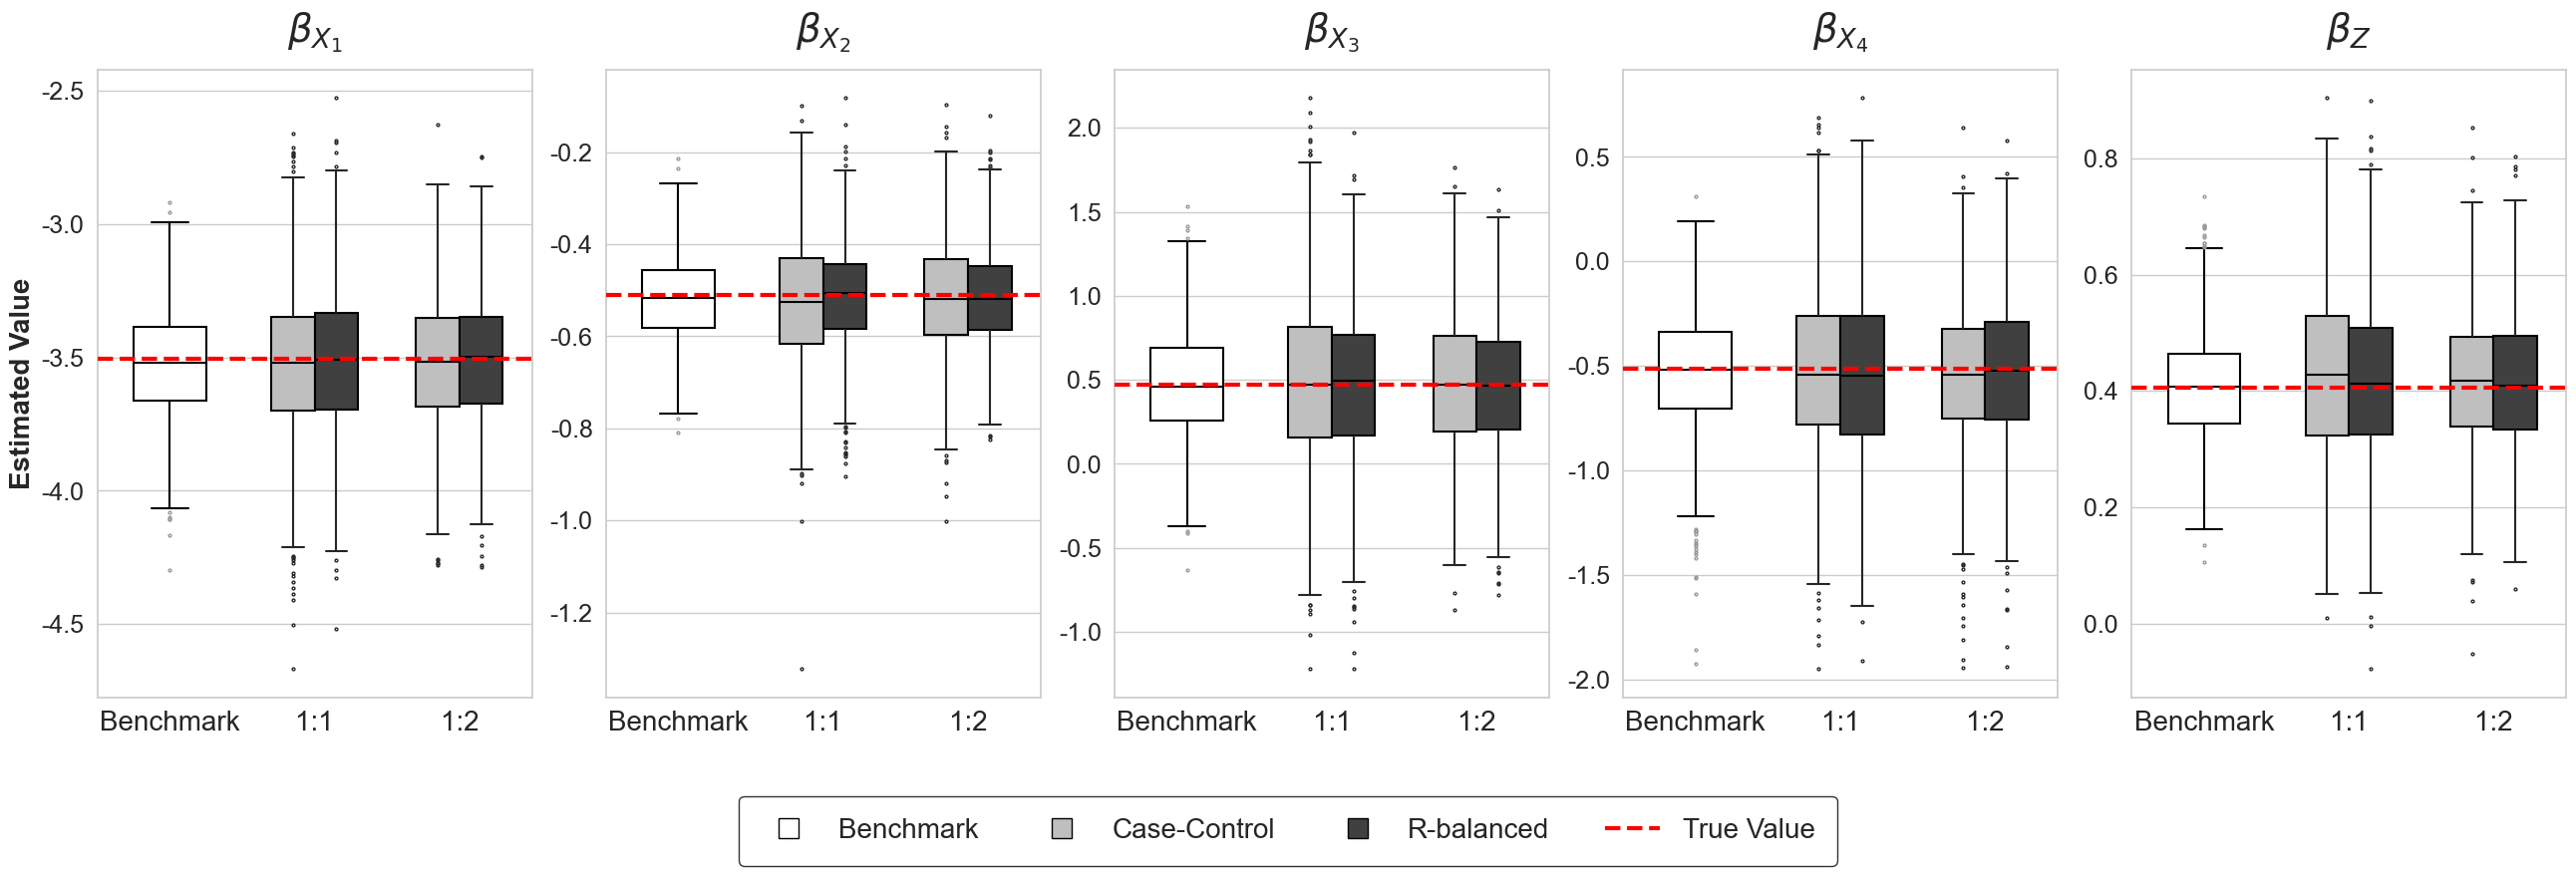

In [15]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import numpy as np
from matplotlib.lines import Line2D

# ================= 1. 配置区域 =================
folders = {
    'benchmark': 'benchmark',
    'case-control': 'case-control',
    'R-balanced': 'R-balanced'
}

# 真值定义 (Rare)
BETA_TRUE_RARE = np.log([0.03, 0.6, 1.6, 0.6, 1.5])

# 标准的数学公式写法，X为变量(斜体)，数字为下标
BETA_NAMES = [
    r"$\beta_{X_1}$",
    r"$\beta_{X_2}$",
    r"$\beta_{X_3}$",
    r"$\beta_{X_4}$",
    r"$\beta_{Z}$"
]

# 🔥 修改点2：黑白打印友好的高对比度灰度配色 🔥
# 使用 matplotlib 的灰度字符串 ('0.0'-黑色 到 '1.0'-白色) 确保打印对比度
PALETTE_SAMPLING = {
    'CC': '0.75',  # 浅灰色 (Light Gray) - 对应原来的浅蓝
    'RB': '0.25'   # 深灰色 (Dark Gray) - 对应原来的深蓝，与浅灰和白色对比鲜明
}

# ================= 2. 数据处理函数 =================
def get_method_label(folder_key, filename):
    if folder_key == 'benchmark': return 'Benchmark'
    match = re.search(r'[-_](\d)\.xlsx$', filename)
    suffix = match.group(1) if match else "1"
    sampling = "1:1" if suffix == "1" else "1:2"
    return f"{'CC' if folder_key == 'case-control' else 'RB'}-{sampling}"

def parse_info(filename):
    match = re.search(r'([MmRr])[-_](\d)', filename)
    if match:
        return match.group(1).upper(), match.group(2)
    return None, None

# ================= 3. 数据加载 =================
all_data = []
# 假设文件夹存在，如需测试请确保路径正确
for key, path in folders.items():
    if not os.path.exists(path): continue
    for file in os.listdir(path):
        if file.endswith('.xlsx') and not file.startswith('~$'):
            t_code, l_code = parse_info(file)
            if t_code == 'R' and l_code == '0':
                m_label = get_method_label(key, file)
                try:
                    df = pd.read_excel(os.path.join(path, file))
                except: continue
                
                target_cols = []
                for i in range(5):
                    for c_name in [f'beta_new_{i}', f'beta_{i}']:
                        if c_name in df.columns:
                            target_cols.append(c_name)
                            break
                
                if len(target_cols) == 5:
                    subset = df[target_cols].copy()
                    subset.columns = [f'beta_{i}' for i in range(5)]
                    melted = subset.melt(var_name='Beta', value_name='Estimated Value')
                    
                    if m_label == 'Benchmark':
                        melted['Ratio'] = 'Benchmark'
                        melted['Method_Type'] = 'Benchmark'
                    else:
                        melted['Ratio'] = '1:1' if '1:1' in m_label else '1:2'
                        melted['Method_Type'] = 'CC' if 'CC' in m_label else 'RB'
                    
                    all_data.append(melted)

if not all_data:
    print("No data found.")
    exit()

full_df = pd.concat(all_data, ignore_index=True)

# ================= 4. 绘图 (核心修改) =================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 5, figsize=(26, 9), sharey=False)

# 强制顺序，确保 Benchmark 在 0，1:1 在 1，1:2 在 2
x_order = ['Benchmark', '1:1', '1:2']

for i in range(5):
    ax = axes[i]
    beta_key = f'beta_{i}'
    
    # 分离数据
    data_bench = full_df[(full_df['Beta'] == beta_key) & (full_df['Ratio'] == 'Benchmark')]
    data_samp  = full_df[(full_df['Beta'] == beta_key) & (full_df['Ratio'] != 'Benchmark')]
    
    # 分两次绘图以保证完美的间距和对齐
    
    # 1. 绘制 Benchmark (固定在位置 0)
    # 使用 color='white' 配合 boxprops 使得箱子为白色且有黑边
    sns.boxplot(
        data=data_bench, x='Ratio', y='Estimated Value',
        order=x_order, # 占位：0=Bench, 1=Empty, 2=Empty
        ax=ax, width=0.5, 
        color='white',  # 纯白填充
        fliersize=2, linewidth=1.5,
        boxprops=dict(edgecolor='black', facecolor='white'),
        medianprops=dict(color='black'),
        whiskerprops=dict(color='black'),
        capprops=dict(color='black')
    )
    
    # 2. 绘制 Sampling (CC/RB) (固定在位置 1 和 2)
    # palette 将使用上面定义的灰度色
    sns.boxplot(
        data=data_samp, x='Ratio', y='Estimated Value', hue='Method_Type',
        order=x_order, # 占位：0=Empty, 1=Data, 2=Data
        hue_order=['CC', 'RB'],
        palette=PALETTE_SAMPLING,
        ax=ax, width=0.6,
        fliersize=2, linewidth=1.5,
        boxprops=dict(edgecolor='black'), # 增加黑边增加对比度
        medianprops=dict(color='black')   # 确保中位数线为黑色
    )
    
    # 真值红线 (红线在黑白打印时通常会显示为深灰/黑色虚线，便于区分)
    ax.axhline(y=BETA_TRUE_RARE[i], color='red', linestyle='--', linewidth=3, label='True Value', zorder=5)
    
    # 标题设置
    ax.set_title(BETA_NAMES[i], fontsize=28, fontweight='bold', pad=20)
    
    # 坐标轴设置
    ax.set_xlabel("") # 移除默认 X 轴标题
    ax.set_ylabel("Estimated Value" if i == 0 else "", fontsize=20, fontweight='bold')
    ax.tick_params(axis='x', labelsize=20)
    ax.tick_params(axis='y', labelsize=18)
    
    # 移除子图图例
    if ax.get_legend(): ax.get_legend().remove()

# ================= 5. 构建图例 (修改标签) =================
legend_elements = [
    # Benchmark: 白色方块黑边
    Line2D([0], [0], color='w', marker='s', markerfacecolor='white', markeredgecolor='black', markersize=14, label='Benchmark'),
    # CC: 浅灰色
    Line2D([0], [0], color='w', marker='s', markerfacecolor=PALETTE_SAMPLING['CC'], markeredgecolor='black', markersize=14, label='Case-Control'),
    # RB: 深灰色
    Line2D([0], [0], color='w', marker='s', markerfacecolor=PALETTE_SAMPLING['RB'], markeredgecolor='black', markersize=14, label='R-balanced'),
    # True Value
    Line2D([0], [0], color='red', lw=3, linestyle='--', label='True Value')
]

lgd = fig.legend(
    handles=legend_elements, 
    loc='lower center', 
    bbox_to_anchor=(0.5, 0.01),
    ncol=4, 
    fontsize=20, 
    frameon=True, 
    edgecolor='black',
    borderpad=0.8
)

plt.tight_layout(rect=[0, 0.15, 1, 1])
# 保存文件名建议加上 bw (black&white) 以示区别
plt.savefig('picture_beta_1.eps', dpi=500, bbox_inches='tight')
plt.show()

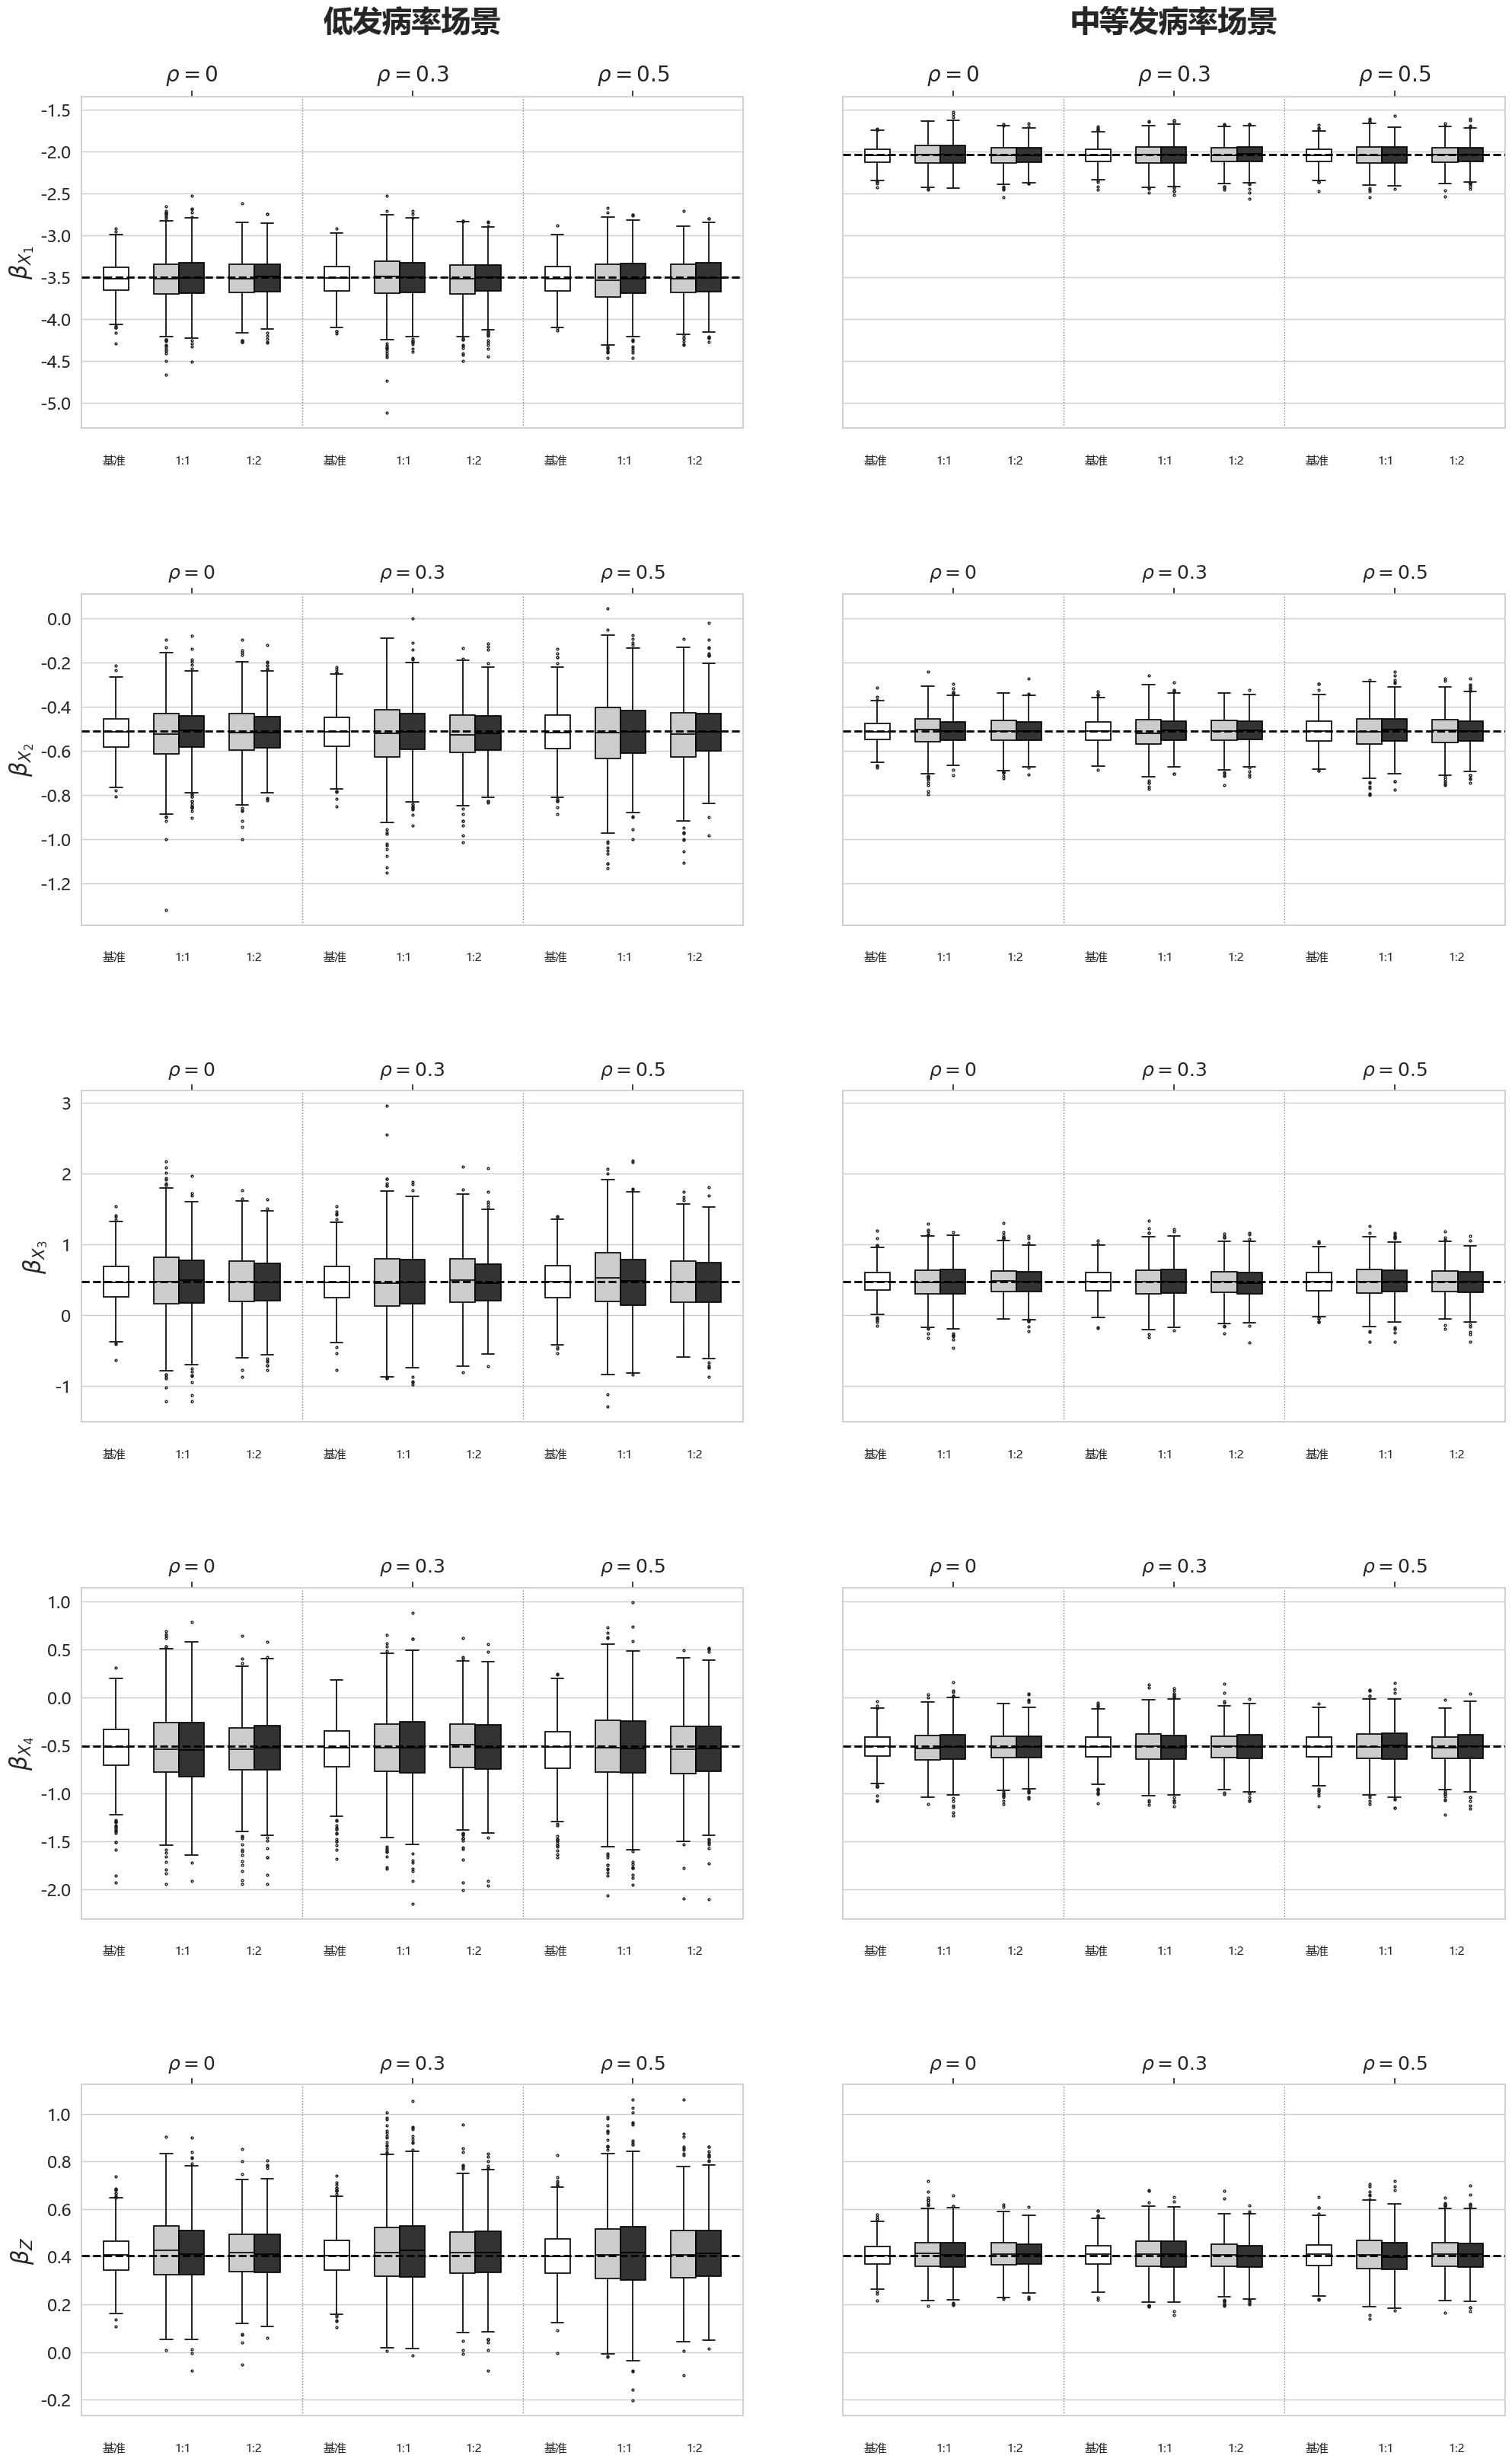

In [16]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import numpy as np
from matplotlib.lines import Line2D

# ================= 0. 中文字体配置 =================
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei'] 
plt.rcParams['axes.unicode_minus'] = False  # 解决坐标轴负号显示为方块的问题

# ================= 1. 配置区域 =================
folders = {
    'benchmark': 'benchmark',
    'case-control': 'case-control',
    'R-balanced': 'R-balanced'
}

LEVEL_MAP = {
    '0': r'$\rho=0$',
    '3': r'$\rho=0.3$',
    '5': r'$\rho=0.5$'
}

# 真值定义
BETA_TRUE_RARE = np.log([0.03, 0.6, 1.6, 0.6, 1.5])
BETA_TRUE_MODER = np.log([0.13, 0.6, 1.6, 0.6, 1.5])

# 数学公式名称
BETA_NAMES = [
    r"$\beta_{X_1}$",
    r"$\beta_{X_2}$",
    r"$\beta_{X_3}$",
    r"$\beta_{X_4}$",
    r"$\beta_{Z}$"
]

# 颜色配置
PALETTE = {
    '基准分析': 'white', 
    '病例-对照抽样-1:1': '0.8', 
    '平衡抽样-1:1': '0.2', 
    '病例-对照抽样-1:2': '0.8', 
    '平衡抽样-1:2': '0.2', 
    'gap1': 'white', 
    'gap2': 'white'
}

# 方法顺序
METHOD_ORDER = [
    '基准分析', 'gap1', 
    '病例-对照抽样-1:1', '平衡抽样-1:1', 
    'gap2', 
    '病例-对照抽样-1:2', '平衡抽样-1:2'
]

# 场景名称映射
TYPE_MAP = {'M': '中等发病率场景', 'R': '低发病率场景'}


# ================= 2. 数据处理 =================
def get_method_label(folder_key, filename):
    if folder_key == 'benchmark': return '基准分析'
    match = re.search(r'[-_](\d)\.xlsx$', filename)
    suffix = match.group(1) if match else "1"
    sampling = "1:1" if suffix == "1" else "1:2"
    
    prefix = '病例-对照抽样' if folder_key == 'case-control' else '平衡抽样'
    return f"{prefix}-{sampling}"

def parse_info(filename):
    match = re.search(r'([MmRr])[-_](\d)', filename)
    if match:
        return TYPE_MAP.get(match.group(1).upper()), LEVEL_MAP.get(match.group(2))
    return None, None

all_data = []
for key, path in folders.items():
    if not os.path.exists(path): continue
    for file in os.listdir(path):
        if file.endswith('.xlsx') and not file.startswith('~$'):
            t_type, l_level = parse_info(file)
            m_meth = get_method_label(key, file)
            if t_type:
                try:
                    df = pd.read_excel(os.path.join(path, file))
                    target_cols = []
                    for i in range(5):
                        for c_name in [f'beta_new_{i}', f'beta_{i}']:
                            if c_name in df.columns:
                                target_cols.append(c_name)
                                break
                    if len(target_cols) == 5:
                        subset = df[target_cols].copy()
                        subset.columns = [f'beta_{i}' for i in range(5)]
                        melted = subset.melt(var_name='Beta', value_name='Value')
                        melted['Type'], melted['Level'], melted['Method'] = t_type, l_level, m_meth
                        all_data.append(melted)
                except: continue

if not all_data:
    print("No data found.")
    exit()

full_df = pd.concat(all_data, ignore_index=True)


# ================= 3. 绘图 =================
plt.close('all')
fig, axes = plt.subplots(5, 2, figsize=(22, 35), sharey='row') 

types = ['低发病率场景', '中等发病率场景']
levels_order = [r'$\rho=0$', r'$\rho=0.3$', r'$\rho=0.5$']

for row_idx in range(5):
    beta_key = f'beta_{row_idx}'
    true_vals = {'低发病率场景': BETA_TRUE_RARE[row_idx], '中等发病率场景': BETA_TRUE_MODER[row_idx]}
    
    for col_idx, t_name in enumerate(types):
        ax = axes[row_idx, col_idx]
        subset = full_df[(full_df['Beta'] == beta_key) & (full_df['Type'] == t_name)]
        
        if not subset.empty:
            sns.boxplot(
                data=subset, x='Level', y='Value', hue='Method',
                hue_order=METHOD_ORDER, order=levels_order,
                palette=PALETTE, ax=ax, 
                fliersize=2, width=0.8, linewidth=1.2,
                boxprops=dict(edgecolor='black'),
                medianprops=dict(color='black'),
                whiskerprops=dict(color='black'),
                capprops=dict(color='black')
            )
            ax.axhline(y=true_vals[t_name], color='black', linestyle='--', linewidth=2, zorder=5)

            # 绘制垂直分割线
            for x_line in [0.5, 1.5]:
                ax.axvline(x=x_line, color='gray', linestyle=':', linewidth=1)

            # 添加底部标签
            trans = ax.get_xaxis_transform()
            for x_i in range(len(levels_order)):
                ax.text(x_i - 0.35, -0.08, "基准", transform=trans, ha='center', va='top', fontsize=11)
                ax.text(x_i - 0.04, -0.08, "1:1", transform=trans, ha='center', va='top', fontsize=11)
                ax.text(x_i + 0.28, -0.08, "1:2", transform=trans, ha='center', va='top', fontsize=11)

        # 标题和轴标签
        if row_idx == 0:
            ax.set_title(f"{t_name}", fontsize=28, fontweight='bold', pad=30)
        
        ax.set_ylabel(BETA_NAMES[row_idx] if col_idx == 0 else "", fontsize=22, fontweight='bold')
        ax.set_xlabel("")
        
        # 设置 X 轴顶部标签
        ax.xaxis.tick_top()
        if row_idx == 0:
            ax.tick_params(axis='x', labelsize=20, labeltop=True)
        else:
            ax.tick_params(axis='x', labelsize=18, labeltop=True) 

        ax.tick_params(axis='y', labelsize=16)
        if ax.get_legend(): ax.get_legend().remove()


# ================= 4. 保存与展示 =================
# 调整子图间距
plt.subplots_adjust(top=0.92, bottom=0.05, hspace=0.5, wspace=0.15, left=0.1, right=0.95)

plt.savefig('picture_beta_test.jpg', dpi=300, bbox_inches='tight')
plt.show()